# Pipeline assembly

In [2]:
import numpy as np
import pandas as pd

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing \
  import FunctionTransformer, OrdinalEncoder, OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: '{:.0f}'.format(x) if int(x) == x else '{:.3f}'.format(x))

In [3]:
# Get Ames housing data
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

In [4]:
# Introduce a new column, HasGarage, either 1/0
df['HasGarage'] = df['GarageCond'].isna().astype(int)

In [5]:
# Map 'CentralAir' to 1/0
df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0}).astype(int)

In [6]:
# Feature columns
features = ['BedroomAbvGr', 'CentralAir', 'HasGarage', 'LotArea',
            'MSSubClass', 'Neighborhood', 'OverallQual', 'TotRmsAbvGrd',
            'YearBuilt']

In [7]:
X = df[features]
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (876, 9) | Val: (292, 9) | Test: (292, 9)


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   BedroomAbvGr  1460 non-null   int64 
 1   CentralAir    1460 non-null   int64 
 2   HasGarage     1460 non-null   int64 
 3   LotArea       1460 non-null   int64 
 4   MSSubClass    1460 non-null   int64 
 5   Neighborhood  1460 non-null   object
 6   OverallQual   1460 non-null   int64 
 7   TotRmsAbvGrd  1460 non-null   int64 
 8   YearBuilt     1460 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 102.8+ KB


In [9]:
X_train.iloc[0], y_train.iloc[0]

(BedroomAbvGr          3
 CentralAir            1
 HasGarage             0
 LotArea            9600
 MSSubClass           70
 Neighborhood    OldTown
 OverallQual           7
 TotRmsAbvGrd          6
 YearBuilt          1925
 Name: 314, dtype: object,
 np.int64(178000))

In [8]:
# One-hot columns
onehot_cols = ['Neighborhood']

# Binary columns
binary_cols = ['CentralAir', 'HasGarage']

# Numeric columns
numeric_cols = [col for col in X_train.select_dtypes(include='number').columns
                if col not in binary_cols]

assert(len(onehot_cols) + len(binary_cols) + len(numeric_cols) \
       == len(features)), "ERROR"

In [9]:
# Create pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

onehot_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("Subpipelines defined")

Subpipelines defined


In [12]:
# --- TARGET ENCODER ---
#from sklearn.preprocessing import TargetEncoder
#te = TargetEncoder()
#out = te.fit_transform(X_train[['Neighborhood']], y_train)

In [11]:
# Assemble column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,  numeric_cols),
        ('bin', binary_pipeline,   binary_cols),
        ('ohe', onehot_pipeline,   onehot_cols),
    ],
    remainder='drop'
)

print('ColumnTransformer assembled')

ColumnTransformer assembled


In [12]:
from sklearn import set_config

set_config(display='diagram')
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['BedroomAbvGr', 'LotArea', 'MSSubClass',
                                  'OverallQual', 'TotRmsAbvGrd', 'YearBuilt']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant'))]),
                                 ['CentralAir', 'HasGarage']),
                                ('ohe',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Neighborhood'])])

In [13]:
# Fit preprocessor alone to inspect output shape and feature names
from sklearn.base import clone

preprocessor_check = clone(preprocessor)
preprocessor_check.fit(X_train)
n_features_out = preprocessor_check.transform(X_train[:1]).shape[1]
print(f'Preprocessor output features: {n_features_out}')
print(f'  Numeric:  {len(numeric_cols)}')
print(f'  Binary:   {len(binary_cols)}')

ohc_enc = preprocessor_check.named_transformers_['ohe'].named_steps['encoder']
ohc_names = ohc_enc.get_feature_names_out(onehot_cols)
print(f'  One-hot: {len(ohc_names)}')
print(f"Total check: {len(numeric_cols) + len(binary_cols)} + "
      f"{len(ohc_names)} == {n_features_out}")

Preprocessor output features: 33
  Numeric:  6
  Binary:   2
  One-hot: 25
Total check: 8 + 25 == 33


In [16]:
preprocessor_check.feature_names_in_, preprocessor_check.get_feature_names_out()

(array(['BedroomAbvGr', 'CentralAir', 'HasGarage', 'LotArea', 'MSSubClass',
        'Neighborhood', 'OverallQual', 'TotRmsAbvGrd', 'YearBuilt'],
       dtype=object),
 array(['num__BedroomAbvGr', 'num__LotArea', 'num__MSSubClass',
        'num__OverallQual', 'num__TotRmsAbvGrd', 'num__YearBuilt',
        'bin__CentralAir', 'bin__HasGarage', 'ohe__Neighborhood_Blmngtn',
        'ohe__Neighborhood_Blueste', 'ohe__Neighborhood_BrDale',
        'ohe__Neighborhood_BrkSide', 'ohe__Neighborhood_ClearCr',
        'ohe__Neighborhood_CollgCr', 'ohe__Neighborhood_Crawfor',
        'ohe__Neighborhood_Edwards', 'ohe__Neighborhood_Gilbert',
        'ohe__Neighborhood_IDOTRR', 'ohe__Neighborhood_MeadowV',
        'ohe__Neighborhood_Mitchel', 'ohe__Neighborhood_NAmes',
        'ohe__Neighborhood_NPkVill', 'ohe__Neighborhood_NWAmes',
        'ohe__Neighborhood_NoRidge', 'ohe__Neighborhood_NridgHt',
        'ohe__Neighborhood_OldTown', 'ohe__Neighborhood_SWISU',
        'ohe__Neighborhood_Sawyer', 'ohe_

# Model training

## Linear Regression

In [14]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_val_pred = lr_pipeline.predict(X_val)
lr_mae  = mean_absolute_error(y_val, lr_val_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
lr_r2   = r2_score(y_val, lr_val_pred)

print(f'Linear Regression -- Val MAE: {lr_mae:.0f} | RMSE: {lr_rmse:.0f} | R2: {lr_r2:.3f}')

Linear Regression -- Val MAE: 26066 | RMSE: 45316 | R2: 0.782


In [15]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_pipeline, X_train, y_train,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse = -cv_scores
print(f'Linear Regression -- 5-Fold CV RMSE: {cv_rmse.mean():.0f} ± {cv_rmse.std():.0f}')
print(f'Individual folds: {[f"{v:.0f}" for v in cv_rmse]}')

Linear Regression -- 5-Fold CV RMSE: 36293 ± 5144
Individual folds: ['36291', '46033', '32201', '35011', '31926']


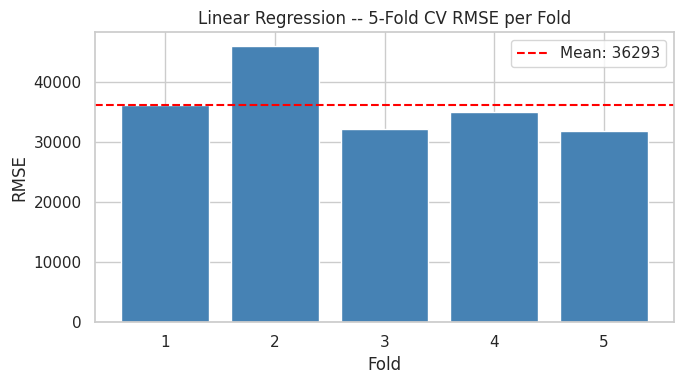

In [19]:
# Bar chart of CV fold scores
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_rmse, color='steelblue')
plt.axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Mean: {cv_rmse.mean():.0f}')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('Linear Regression -- 5-Fold CV RMSE per Fold')
plt.legend()
plt.tight_layout()
plt.show()

## Random Forest

In [16]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

rf_val_pred = rf_pipeline.predict(X_val)
rf_mae  = mean_absolute_error(y_val, rf_val_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_r2   = r2_score(y_val, rf_val_pred)

print(f'Random Forest    -- Val MAE: {rf_mae:.0f} | RMSE: {rf_rmse:.0f} | R2: {rf_r2:.3f}')

Random Forest    -- Val MAE: 25957 | RMSE: 40747 | R2: 0.824


In [21]:
rf_cv = cross_val_score(rf_pipeline, X_train, y_train,
                        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_cv_rmse = -rf_cv
print(f'Random Forest -- 5-Fold CV RMSE: {rf_cv_rmse.mean():.0f} ± {rf_cv_rmse.std():.0f}')
print(f'Individual folds: {[f"{v:.0f}" for v in rf_cv_rmse]}')

Random Forest -- 5-Fold CV RMSE: 35563 ± 4037
Individual folds: ['35971', '43214', '33697', '32231', '32700']


## Model comparison

In [17]:
comparison = pd.DataFrame([
    {'model': 'LinearRegression', 'val_mae': lr_mae, 'val_rmse': lr_rmse, 'val_r2': lr_r2},
    {'model': 'RandomForest',     'val_mae': rf_mae, 'val_rmse': rf_rmse, 'val_r2': rf_r2},
]).sort_values('val_rmse')
comparison

,model,val_mae,val_rmse,val_r2
1,RandomForest,25957.004,40747.032,0.824
0,LinearRegression,26066.423,45315.889,0.782


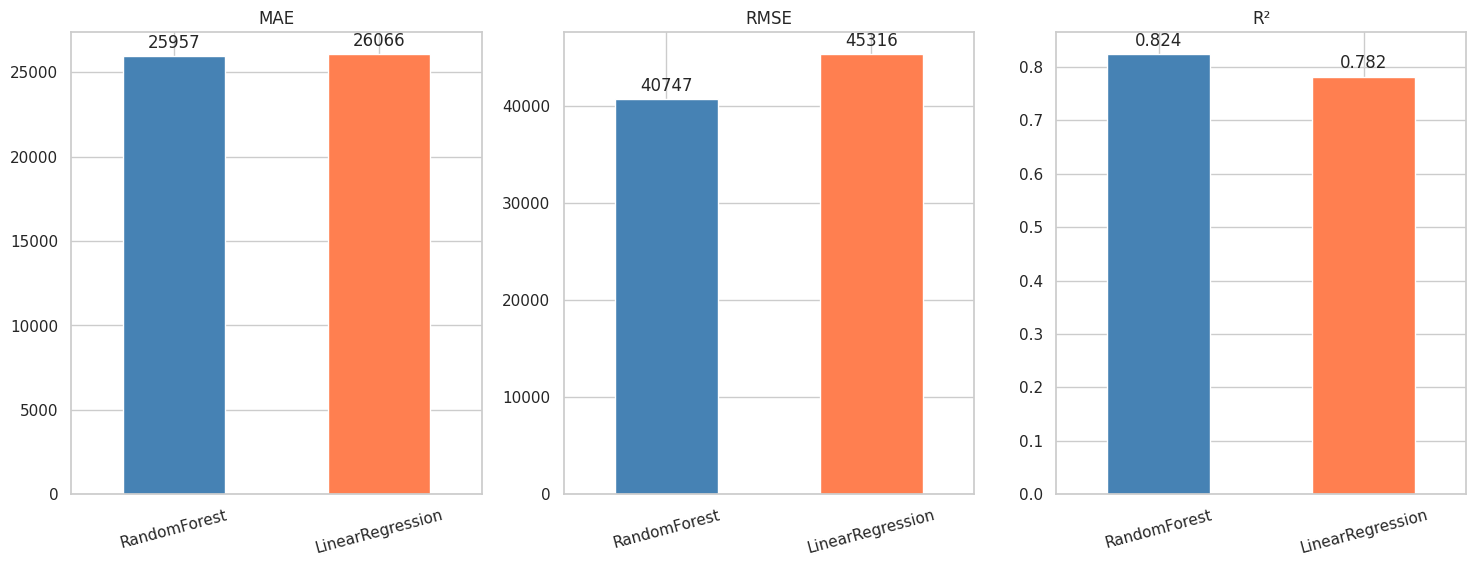

In [19]:
# Bar chart comparison of MAE and RMSE
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

comparison.plot(kind='bar', x='model', y='val_mae', ax=axes[0], legend=False, color=['steelblue', 'coral'])
axes[0].set_title('MAE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3)

comparison.plot(kind='bar', x='model', y='val_rmse', ax=axes[1], legend=False, color=['steelblue', 'coral'])
axes[1].set_title('RMSE')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)

comparison.plot(kind='bar', x='model', y='val_r2', ax=axes[2], legend=False, color=['steelblue', 'coral'])
axes[2].set_title('R²')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.3f', padding=3)

In [24]:
# Better model is Random Forest
best_model = rf_pipeline

joblib.dump(best_model, 'w2_real_estate_agent.joblib')

# Verify loaded model works on raw data
loaded_model = joblib.load('w2_real_estate_agent.joblib')
raw_sample = X_val.iloc[:5].copy()
preds = loaded_model.predict(raw_sample)
actuals = y_val.iloc[:5].values

print('Loaded pipeline predictions on 5 raw validation rows:')
for i, (pred, actual) in enumerate(zip(preds, actuals)):
    diff = pred - actual
    print(f"  Row {i}: predicted = ${pred:8,.0f}  "
          f"actual = ${actual:8,.0f}  diff = ${diff:+8,.0f}")

Loaded pipeline predictions on 5 raw validation rows:
  Row 0: predicted = $ 149,892  actual = $ 135,000  diff = $ +14,892
  Row 1: predicted = $ 375,938  actual = $ 501,837  diff = $-125,899
  Row 2: predicted = $ 336,311  actual = $ 305,000  diff = $ +31,311
  Row 3: predicted = $ 118,506  actual = $ 125,000  diff = $  -6,494
  Row 4: predicted = $ 400,220  actual = $ 556,581  diff = $-156,360


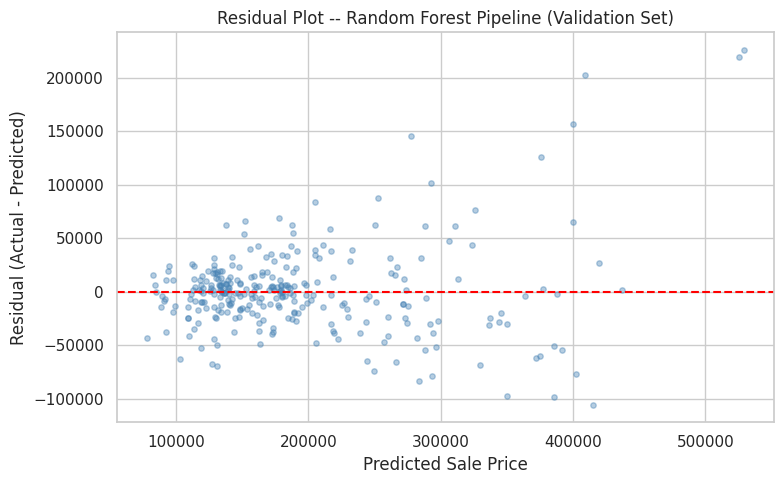

In [25]:
# Residual plot for best pipeline on validation set
residuals = y_val - rf_val_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_val_pred, residuals, alpha=0.4, s=15, color='steelblue')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot -- Random Forest Pipeline (Validation Set)')
plt.tight_layout()
plt.show()

Here is the first batch of results, where `YearRemodAdd` is used as a feature.

Random Forest does better, here are the stats:
```
Random Forest -- Val MAE: 25796 | RMSE: 40451 | R2: 0.826
Random Forest -- 5-Fold CV RMSE: 34967 ± 3997
```

Tested on 5 raw validation rows:
```
  Row 0: predicted = $ 145,452  actual = $ 135,000  diff = $ +10,452
  Row 1: predicted = $ 396,297  actual = $ 501,837  diff = $-105,540
  Row 2: predicted = $ 331,827  actual = $ 305,000  diff = $ +26,827
  Row 3: predicted = $ 124,262  actual = $ 125,000  diff = $    -738
  Row 4: predicted = $ 391,895  actual = $ 556,581  diff = $-164,686
```

---

Here is the second batch of results, where `YearRemodAdd` is not used as a feature. Now we only have 8 features instead of 9.

Again, Random Forest is better than Linear Reg:
```
Random Forest -- Val MAE: 25957 | RMSE: 40747 | R2: 0.824
Random Forest -- 5-Fold CV RMSE: 35563 ± 4037
```

Tested on 5 raw validation rows:
```
  Row 0: predicted = $ 149,892  actual = $ 135,000  diff = $ +14,892
  Row 1: predicted = $ 375,938  actual = $ 501,837  diff = $-125,899
  Row 2: predicted = $ 336,311  actual = $ 305,000  diff = $ +31,311
  Row 3: predicted = $ 118,506  actual = $ 125,000  diff = $  -6,494
  Row 4: predicted = $ 400,220  actual = $ 556,581  diff = $-156,360
```

**Conclusion:** Let's use the 8-feature version, without `YearRemodAdd` for now.

# Summary stats generation

In [98]:
import json
stats = y_train.describe()
stats['10%'] = y_train.quantile(0.1)
stats['90%'] = y_train.quantile(0.9)
A = { x: int(y) for x, y in zip(stats.index, stats.values) }
json.dumps(A)

'{"count": 876, "mean": 179921, "std": 75389, "min": 34900, "25%": 129000, "50%": 164945, "75%": 213625, "max": 625000, "10%": 106375, "90%": 275000}'

In [99]:
dfx = X_train.copy()
dfx['SalePrice'] = y_train
means = dfx.groupby('Neighborhood')['SalePrice'].mean()
B = { x: int(y) for x, y in zip(means.index, means.values) }
json.dumps(B)

'{"Blmngtn": 192309, "Blueste": 124000, "BrDale": 102208, "BrkSide": 118719, "ClearCr": 229323, "CollgCr": 198873, "Crawfor": 219190, "Edwards": 132334, "Gilbert": 197459, "IDOTRR": 107985, "MeadowV": 101890, "Mitchel": 161715, "NAmes": 148366, "NPkVill": 147125, "NWAmes": 191252, "NoRidge": 311953, "NridgHt": 315890, "OldTown": 132300, "SWISU": 141782, "Sawyer": 138267, "SawyerW": 174203, "Somerst": 217048, "StoneBr": 288517, "Timber": 233982, "Veenker": 265416}'